In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

In [4]:
data = pd.read_csv("dataset.csv")

In [5]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Churn Distribution')

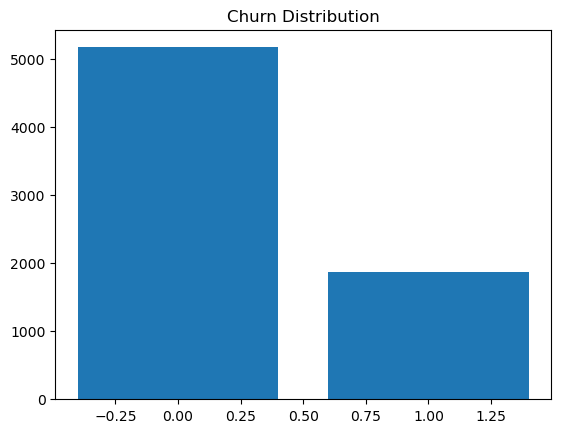

In [31]:
churn_counts = data['Churn'].value_counts()
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Churn Distribution")


In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in data.select_dtypes(include='object'):
    data[col] = le.fit_transform(data[col])

In [33]:
from imblearn.over_sampling import SMOTE

In [34]:
x = data.drop('Churn', axis=1)
y = data['Churn']
smote = SMOTE()
x_res, y_res = smote.fit_resample(x, y)

<Axes: xlabel='Churn', ylabel='count'>

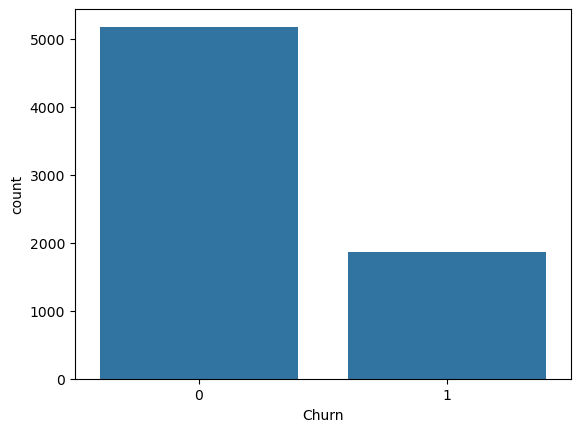

In [35]:
sns.countplot(x='Churn',data=data)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2)

In [39]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\preet\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [47]:
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8521739130434782
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1069
           1       0.85      0.84      0.85      1001

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



In [54]:
import joblib
joblib.dump(xgb, "churn_model.pkl")
joblib.dump(x.columns, "columns.pkl")

['columns.pkl']

In [49]:
model = joblib.load("churn_model.pkl")


In [50]:
prediction = model.predict(X_test[:5])
print(prediction)

[0 0 1 1 0]


In [51]:
import streamlit as st

In [52]:
st.title("Customer Churn Prediction")

tenure = st.slider("Tenure", 0, 72)
monthly = st.number_input("Monthly Charges")

if st.button("Predict"):
    data = [[tenure, monthly]]
    result = model.predict(data)
    
    if result[0] == 1:
        st.error("Customer will churn")
    else:
        st.success("Customer will stay")

2026-05-04 21:57:12.959 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 21:57:13.345 
  command:

    streamlit run C:\Users\preet\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-04 21:57:13.348 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 21:57:13.349 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 21:57:13.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 21:57:13.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 21:57:13.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 21:57:13.355 Thread 'MainThread': mi